# Open-Loop Optimal Control for an Inverted Pendulum on a Cart

This notebook demonstrates how to formulate and solve an open-loop optimal control problem (OCP) for an inverted pendulum on a cart using the `OCP` class from the `model_predictive_control` package.

The goal is to stabilize the pendulum in the upright position starting from an initial offset angle.


In [ ]:
import casadi as ca
import matplotlib.pyplot as plt
import numpy as np

from model_predictive_control.ocp import OCP
from model_predictive_control.plots import plot_controls, plot_states

## 1. System Dynamics

We define the physical parameters of the inverted pendulum and derive the equations of motion using CasADi symbolic variables.

- $p$: Cart position
- $v$: Cart velocity
- $\theta$: Pendulum angle (0 is upright)
- $\omega$: Pendulum angular velocity
- $u$: Force applied to the cart


In [ ]:
# Physical parameters
M = 1.0  # Mass of the cart (kg)
m = 0.1  # Mass of the pendulum (kg)
l = 0.5  # Length of the pendulum (m)  # noqa: E741
g = 9.81  # Gravity (m/s^2)

# Define dimensions
nx = 4
nu = 1

# CasADi symbolic variables
x = ca.MX.sym("x", nx)
u = ca.MX.sym("u", nu)

p, v, theta, omega = x[0], x[1], x[2], x[3]

# Non-linear dynamics equations
sin_theta = ca.sin(theta)
cos_theta = ca.cos(theta)
denominator = M + m - m * cos_theta**2

# Accelerations
p_ddot = (u[0] + m * l * omega**2 * sin_theta - m * g * sin_theta * cos_theta) / denominator
theta_ddot = (-u[0] * cos_theta - m * l * omega**2 * sin_theta * cos_theta + (M + m) * g * sin_theta) / (
    l * denominator
)

# Continuous time state derivative
x_dot = ca.vertcat(v, p_ddot, omega, theta_ddot)

# Create CasADi function for dynamics
dynamics = ca.Function("dynamics", [x, u], [x_dot])

## 2. Objective Function

We define a quadratic cost function to penalize deviation from the origin (upright position at the center) and control effort. We also define a terminal cost to ensure stability at the end of the horizon.


In [15]:
# State cost matrix (penalize position, velocity, angle, angular velocity)
Q = np.diag([10.0, 1.0, 10.0, 1.0])

# Control cost matrix (penalize force)
R = np.array([[0.1]])

# Stage cost function
cost = x.T @ Q @ x + u.T @ R @ u
objective = ca.Function("objective", [x, u], [cost])

# Terminal cost matrix (higher penalty for final state to ensure reaching the target)
Qf = np.diag([100.0, 10.0, 100.0, 10.0])
terminal_cost = x.T @ Qf @ x
terminal_objective = ca.Function("terminal_objective", [x], [terminal_cost])

## 3. Constraints

We add inequalities to restrict the control force and the cart's position so it stays within physical limits.


In [16]:
# Control limits
u_max = 10.0  # Maximum force (N)

# State limits (Position)
p_max = 2.0  # Maximum track length bounds (m)

# Inequality constraints must return values <= 0
ineq_expr = ca.vertcat(
    u[0] - u_max,  # u <= u_max
    -u[0] - u_max,  # -u <= u_max => u >= -u_max
    p - p_max,  # p <= p_max
    -p - p_max,  # p >= -p_max
)

in_eq_constraints = ca.Function("in_eq", [x, u], [ineq_expr])

## 4. Problem Setup and Solving

We configure the OCP using Hermite-Simpson direct collocation over a prediction horizon.


In [17]:
# OCP configuration
N = 100  # Number of intervals
dt = 0.05  # Time step (s)

# Initial state: Cart at origin, pendulum offset by 0.5 radians (~28.6 degrees)
x0_val = np.array([0.0, 0.0, 0.5, 0.0])

# Instantiate OCP
ocp = OCP(
    N=N,
    dt=dt,
    objective=objective,
    dynamics=dynamics,
    terminal_objective=terminal_objective,
    in_eq_constraints=in_eq_constraints,
)

# Setup the problem formulation and solver
ocp.setup(
    method="collocation", dynamics_type="continuous", solver="ipopt", solver_opts={"print_level": 5, "max_iter": 1000}
)

# Solve the OCP
print(f"Solving OCP starting from initial state: {x0_val}")
X_opt, U_opt, status = ocp.solve(x0_val)

print(f"\nSolver Status: {status}")

Solving OCP starting from initial state: [0.  0.  0.5 0. ]
This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     2604
Number of nonzeros in inequality constraint Jacobian.:      400
Number of nonzeros in Lagrangian Hessian.............:     1405

Total number of variables............................:      504
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:      404
Total number of inequality constraints...............:      400
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:      400

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  0.0000000e+0

## 5. Visualizing the Results

Let's plot the optimal state and control trajectories to verify the performance.


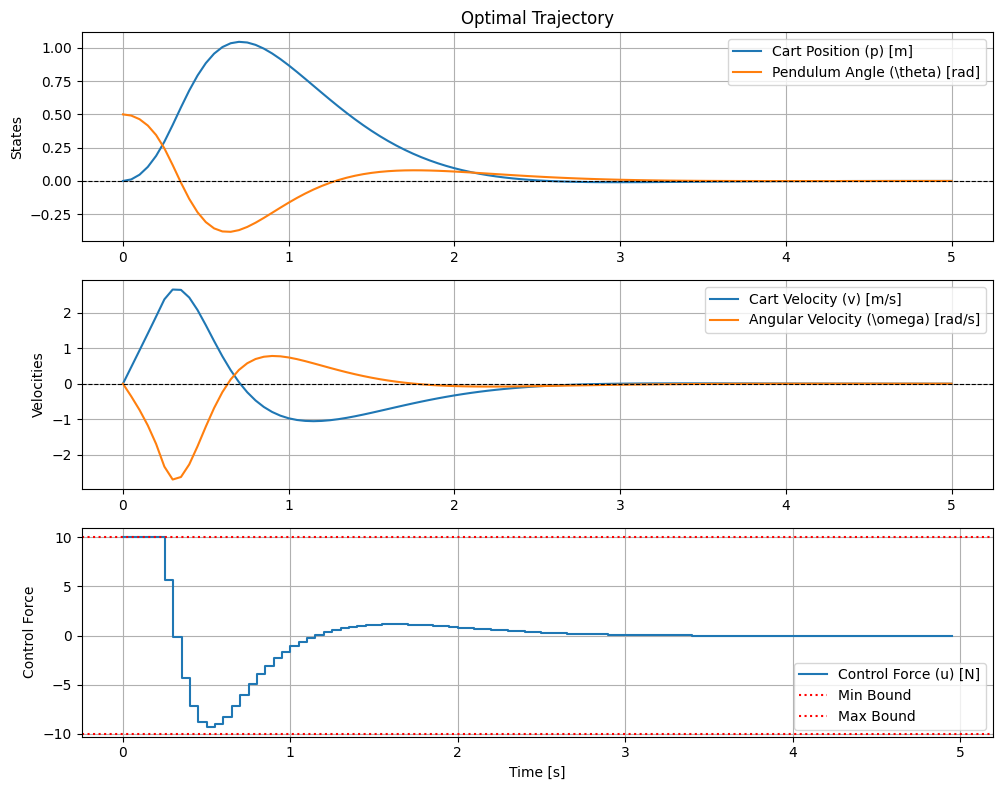

In [18]:
time = np.arange(0, N + 1) * dt

fig, axs = plt.subplots(3, 1, figsize=(10, 8))

# Plot Position and Angle
plot_states(
    time,
    X_opt,
    indices=[0, 2],
    labels=["Cart Position (p) [m]", "Pendulum Angle (\\theta) [rad]"],
    fig=fig,
    ax=axs[0],
    title="Optimal Trajectory",
)
axs[0].axhline(0, color="black", linestyle="--", linewidth=0.8)

# Plot Velocities
plot_states(
    time,
    X_opt,
    indices=[1, 3],
    labels=["Cart Velocity (v) [m/s]", "Angular Velocity (\\omega) [rad/s]"],
    fig=fig,
    ax=axs[1],
    ylabel="Velocities",
)
axs[1].axhline(0, color="black", linestyle="--", linewidth=0.8)

# Plot Control Force
plot_controls(
    time,
    U_opt,
    indices=[0],
    labels=["Control Force (u) [N]"],
    fig=fig,
    ax=axs[2],
    ylabel="Control Force",
    bounds=[(-u_max, u_max)],
)

plt.tight_layout()
plt.show()